1. Environment Setup and Custom Model Loading:

We'll load the custom model and prepare it for both slicing (SAHI) and tracking (ByteTrack).

In [7]:
import os
from sahi import AutoDetectionModel
import supervision as sv
from ultralytics import YOLO

# Debug step: Check if the model file exists
yolov8_model_path = "runs/detect/train/weights/best.pt"
if not os.path.exists(yolov8_model_path):
    raise FileNotFoundError(f"Model not found at {yolov8_model_path}")

# Debug step: Load the detection model (custom trained for basketball tracking)
detection_model = AutoDetectionModel.from_pretrained(
    model_type="yolov8",
    model_path=yolov8_model_path,
    confidence_threshold=0.3,
    device="cuda"  # Switch to "cpu" if you're not using a GPU
)

# Load YOLO model for tracking
yolo_model = YOLO(yolov8_model_path)

# Debug: Print model details to confirm loading
print(f"SAHI detection model loaded: {detection_model}")
print(f"YOLO tracking model loaded: {yolo_model}")


SAHI detection model loaded: <sahi.models.yolov8.Yolov8DetectionModel object at 0x7f17e3963be0>
YOLO tracking model loaded: YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 80, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(80, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(80, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(160, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(160, 160, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(160, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(400, 160, ke

2. Video Download and Preparation:

Here, we ensure the video is available for tracking.

In [8]:
import yt_dlp

# Debug: Download the video only if not present
source_video_path = "../data/videos/downloaded/downloaded_video.mp4"
if not os.path.exists(source_video_path):
    def download_video(url, output_path):
        ydl_opts = {
            'format': 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/mp4',
            'outtmpl': output_path,
            'merge_output_format': 'mp4',
        }
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            ydl.download([url])

    # Example video URL (replace with actual)
    video_url = 'https://www.youtube.com/watch?v=NfBnY3ztFVc'
    download_video(video_url, source_video_path)
    print(f"Downloaded video to {source_video_path}")
else:
    print(f"Video already downloaded: {source_video_path}")


Video already downloaded: ../data/videos/downloaded/downloaded_video.mp4


3. SAHI Slicing and Prediction:

Here, we'll perform the SAHI slicing and make predictions on the sliced frames.


image 1/1 /workspaces/basketball_homography/notebooks/../data/images/basketball-and-hoop-12/test/images/-_20230317104113_png.rf.9629016382d53426f73dcc89eb5b764d.jpg: 640x640 1 Basketball, 1 Player, 77.0ms
Speed: 3.0ms preprocess, 77.0ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


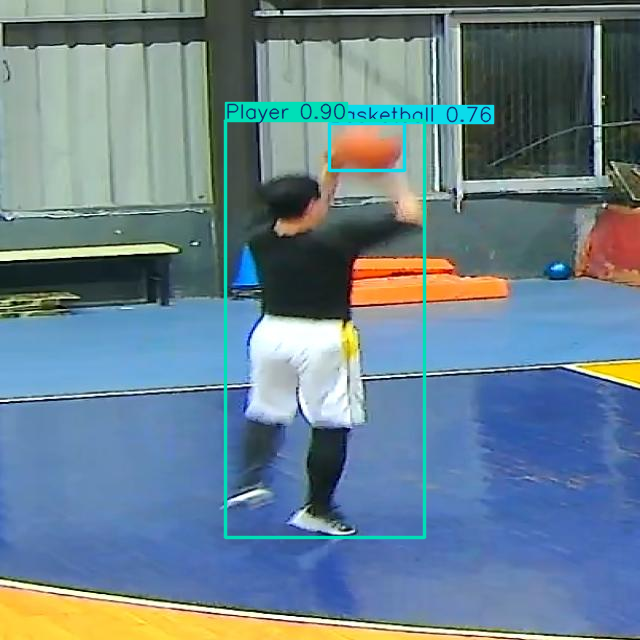

In [12]:
# ***Without SAHI

# Perform object detection on an image
results = yolo_model("../data/images/basketball-and-hoop-12/test/images/-_20230317104113_png.rf.9629016382d53426f73dcc89eb5b764d.jpg")

# Display the results
results[0].show()

Performing prediction on 9 slices.
Prediction complete. Visuals exported: [ObjectPrediction<
    bbox: BoundingBox: <(328.3867416381836, 118.04158782958984, 404.7453556060791, 171.1006622314453), w: 76.35861396789551, h: 53.05907440185547>,
    mask: None,
    score: PredictionScore: <value: 0.8609423637390137>,
    category: Category: <id: 1, name: Basketball>>, ObjectPrediction<
    bbox: BoundingBox: <(225.534912109375, 118.52644348144531, 426.957763671875, 537.963623046875), w: 201.4228515625, h: 419.4371795654297>,
    mask: None,
    score: PredictionScore: <value: 0.9035633206367493>,
    category: Category: <id: 3, name: Player>>]


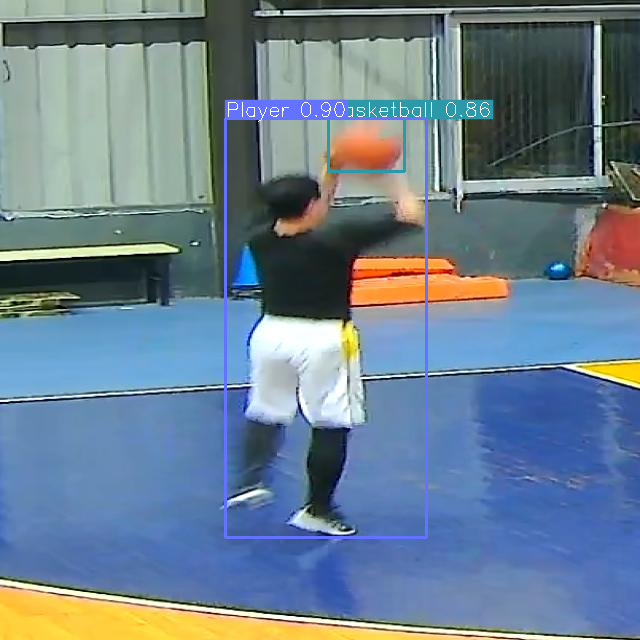

In [14]:
from sahi.predict import get_sliced_prediction
from IPython.display import Image

# ***With SAHI

# Debug: Perform SAHI slicing and prediction on one frame to verify slicing works
result = get_sliced_prediction(
    "../data/images/basketball-and-hoop-12/test/images/-_20230317104113_png.rf.9629016382d53426f73dcc89eb5b764d.jpg",  # Example image from the video
    detection_model,
    slice_height=256,  # Customize slice height and width for your use case
    slice_width=256,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2
)

# Debug: Check the object detection results and the export directory
result.export_visuals(export_dir="../data/images/results")
print(f"Prediction complete. Visuals exported: {result.object_prediction_list}")

# Display the resulting visual
Image("../data/images/results/prediction_visual.png")


4. Integrating SAHI with ByteTrack for Object Tracking:

We'll now integrate ByteTrack for tracking objects across frames using detections from the SAHI slice inference.

In [20]:
# %% [markdown]
# # Integrating SAHI Object Detection with Supervision Tracking for Basketball Video

# %% [markdown]
# This notebook demonstrates how to integrate SAHI's sliced inference with Supervision's tracking capabilities using a custom YOLOv8 model trained for basketball tracking. The workflow is modularized into functions for clarity and maintainability.

# %% [markdown]
# ## 1. Setup and Installation

# %%
def install_dependencies():
    """
    Installs the required Python libraries.
    
    **Purpose:**
    - Ensures that all necessary libraries are installed before proceeding.
    
    **Libraries:**
    - `sahi`: For sliced inference in object detection.
    - `supervision`: For object tracking and annotation.
    - `ultralytics`: For YOLOv8 model handling.
    - `yt-dlp`: For downloading YouTube videos.
    
    **Usage:**
    Run this function at the beginning of the notebook to install dependencies.
    """
    import sys
    import subprocess

    def install(package):
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

    # List of required packages
    packages = [
        "sahi",
        "supervision",
        "ultralytics",
        "yt-dlp"
    ]

    for package in packages:
        try:
            __import__(package)
            print(f"'{package}' is already installed.")
        except ImportError:
            print(f"Installing '{package}'...")
            install(package)
            print(f"'{package}' installed successfully.")

# Uncomment the following line to install dependencies
# install_dependencies()

# %% [markdown]
# ## 2. Downloading and Preparing the Models

# %%
import os
import torch
from sahi.utils.yolov8 import download_yolov8s_model
from sahi import AutoDetectionModel
from ultralytics import YOLO

def download_yolo_model(model_path):
    """
    Downloads the YOLOv8s model if the custom model is not present.

    **Parameters:**
    - `model_path` (str): The filesystem path where the YOLOv8 model is or will be stored.

    **Behavior:**
    - Checks if the model exists at `model_path`.
    - If not, downloads the YOLOv8s model as a placeholder.
    """
    print(f"Checking for YOLOv8 model at {model_path}...")
    if not os.path.exists(model_path):
        print("YOLOv8 model not found. Downloading YOLOv8s model as a placeholder.")
        download_yolov8s_model(model_path)
        print("Downloaded YOLOv8s model as a placeholder.")
    else:
        print("YOLOv8 model found.")

def initialize_sahi_model(model_path):
    """
    Initializes the SAHI Detection Model with the specified YOLOv8 weights.

    **Parameters:**
    - `model_path` (str): Path to the YOLOv8 model weights.

    **Returns:**
    - `detection_model` (sahi.models.yolov8.Yolov8DetectionModel): The initialized SAHI detection model.
    """
    print("\nInitializing SAHI detection model...")
    detection_model = AutoDetectionModel.from_pretrained(
        model_type="yolov8",
        model_path=model_path,
        confidence_threshold=0.3,
        device="cuda" if torch.cuda.is_available() else "cpu"  # Automatically select device
    )
    print("SAHI detection model initialized successfully.")
    return detection_model

def initialize_supervision_model(model_path):
    """
    Initializes the Supervision YOLOv8 model.

    **Parameters:**
    - `model_path` (str): Path to the YOLOv8 model weights.

    **Returns:**
    - `supervision_model` (ultralytics.YOLO): The initialized Supervision YOLOv8 model.
    """
    print("\nInitializing Supervision YOLOv8 model...")
    supervision_model = YOLO(model_path)
    print("Supervision YOLOv8 model initialized successfully.")
    return supervision_model

def print_model_summaries(detection_model, supervision_model):
    """
    Prints summaries of the SAHI and Supervision models for debugging purposes.

    **Parameters:**
    - `detection_model` (sahi.models.yolov8.Yolov8DetectionModel): The SAHI detection model.
    - `supervision_model` (ultralytics.YOLO): The Supervision YOLOv8 model.
    """
    print("\n--- SAHI Detection Model Summary ---")
    print(detection_model)
    
    print("\n--- Supervision YOLOv8 Model Summary ---")
    print(supervision_model)

# Define paths
custom_model_path = "runs/detect/train/weights/best.pt"  # Replace with your custom model path

# Download or verify the YOLOv8 model
download_yolo_model(custom_model_path)

# Initialize models
detection_model_sahi = initialize_sahi_model(custom_model_path)
supervision_model = initialize_supervision_model(custom_model_path)

# Debug: Print model summaries
print_model_summaries(detection_model_sahi, supervision_model)

# %% [markdown]
# ## 3. Downloading the Video

# %%
import yt_dlp

def download_video(video_url, output_path):
    """
    Downloads a YouTube video using yt-dlp.

    **Parameters:**
    - `video_url` (str): URL of the YouTube video to download.
    - `output_path` (str): Filesystem path where the downloaded video will be saved.

    **Behavior:**
    - Downloads the best available video and audio streams.
    - Merges them into an MP4 file at `output_path`.
    """
    ydl_opts = {
        'format': 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/mp4',  # Download best video and audio
        'outtmpl': output_path,  # Set output filename
        'merge_output_format': 'mp4',  # Ensure MP4 format
        'quiet': False,  # Enable verbose output
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([video_url])

def ensure_video_downloaded(video_url, output_path):
    """
    Ensures that the video is downloaded. If not, downloads it.

    **Parameters:**
    - `video_url` (str): URL of the YouTube video to download.
    - `output_path` (str): Filesystem path where the downloaded video will be saved.
    """
    if not os.path.exists(output_path):
        print(f"\nVideo not found at {output_path}. Downloading...")
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        download_video(video_url, output_path)
        print(f"Downloaded video to {output_path}")
    else:
        print(f"\nVideo already exists at {output_path}. Skipping download.")

# Define the YouTube video URL and download path
video_url = 'https://www.youtube.com/watch?v=NfBnY3ztFVc'
source_video_path = "../data/videos/downloaded/downloaded_video.mp4"

# Ensure the video is downloaded
ensure_video_downloaded(video_url, source_video_path)

# %% [markdown]
# ## 4. Initializing Supervision Tracker and Annotators

# %%
import numpy as np
import supervision as sv

def initialize_tracker():
    """
    Initializes the Supervision tracker.

    **Returns:**
    - `tracker` (sv.ByteTrack): The initialized ByteTrack tracker.
    
    **Options:**
    - You can choose different trackers like `sv.DeepSort` based on your requirements.
    """
    print("\nInitializing Supervision tracker...")
    tracker = sv.ByteTrack()  # You can choose other trackers like DeepSort, etc.
    print("Supervision tracker initialized.")
    return tracker

def initialize_annotators():
    """
    Initializes the Supervision annotators for bounding boxes, labels, and traces.

    **Returns:**
    - `box_annotator` (sv.BoxAnnotator): Annotator for bounding boxes.
    - `label_annotator` (sv.LabelAnnotator): Annotator for labels.
    - `trace_annotator` (sv.TraceAnnotator): Annotator for movement traces.
    
    **Annotator Details:**
    - **BoxAnnotator:**
        - `color`: Color of the bounding box in BGR.
        - `thickness`: Thickness of the bounding box lines.
    - **LabelAnnotator:**
        - `color`: Color of the label text in BGR.
        - `text_thickness`: Thickness of the label text.
        - `text_scale`: Scale of the label text.
    - **TraceAnnotator:**
        - `color`: Color of the traces in BGR.
        - `thickness`: Thickness of the trace lines.
        - `trace_length`: Number of previous positions to display.
        - **Note:** The `alpha` parameter has been removed as it caused errors.
    """
    print("\nInitializing Supervision annotators...")
    
    # BoxAnnotator: Draws bounding boxes around detections
    box_annotator = sv.BoxAnnotator(
        color=(255, 0, 0),       # Red color in BGR
        thickness=2               # Thickness of the bounding box lines
    )
    
    # LabelAnnotator: Adds labels to bounding boxes
    label_annotator = sv.LabelAnnotator(
        color=(255, 255, 255),    # White color for text in BGR
        text_thickness=1,          # Thickness of the label text
        text_scale=0.5             # Scale of the label text
    )
    
    # TraceAnnotator: Draws traces of object movements
    trace_length = 20  # Define trace_length separately if needed
    trace_annotator = sv.TraceAnnotator(
        color=(0, 255, 0),         # Green color for traces in BGR
        thickness=2,               # Thickness of the trace lines
        trace_length=trace_length  # Number of previous positions to display
        # 'alpha' parameter removed due to unsupported argument
    )
    
    print("Supervision annotators initialized.")
    
    # Debug: Print annotator configurations
    print("\n--- Annotator Configurations ---")
    print(f"BoxAnnotator: color={box_annotator.color}, thickness={box_annotator.thickness}")
    print(f"LabelAnnotator: color={label_annotator.color}, text_thickness={label_annotator.text_thickness}, text_scale={label_annotator.text_scale}")
    print(f"TraceAnnotator: color={trace_annotator.color}, thickness={trace_annotator.thickness}, trace_length={trace_length}")
    
    return box_annotator, label_annotator, trace_annotator

# Initialize tracker and annotators
tracker = initialize_tracker()
box_annotator, label_annotator, trace_annotator = initialize_annotators()


# %% [markdown]
# ## 5. Processing the Video with Detection and Tracking

# %%
import cv2

def process_video(source_path, output_path, detection_model, supervision_model, tracker, annotators):
    """
    Processes the video by performing detection, tracking, annotation, and writing the output.

    **Parameters:**
    - `source_path` (str): Path to the input video file.
    - `output_path` (str): Path where the annotated output video will be saved.
    - `detection_model` (sahi.models.yolov8.Yolov8DetectionModel): The SAHI detection model.
    - `supervision_model` (ultralytics.YOLO): The Supervision YOLOv8 model.
    - `tracker` (sv.ByteTrack): The Supervision tracker.
    - `annotators` (tuple): A tuple containing `box_annotator`, `label_annotator`, and `trace_annotator`.
    
    **Behavior:**
    - Reads the input video frame by frame.
    - Performs sliced inference using SAHI on each frame to detect objects.
    - Updates the tracker with current detections.
    - Annotates the frame with bounding boxes, labels, and movement traces.
    - Writes the annotated frame to the output video.
    
    **Error Handling:**
    - Catches and logs exceptions during detection to prevent halting the entire process.
    """
    box_annotator, label_annotator, trace_annotator = annotators
    
    # Open the source video
    print(f"\nOpening video file {source_path}...")
    video_capture = cv2.VideoCapture(source_path)
    
    if not video_capture.isOpened():
        raise IOError(f"Cannot open video file {source_path}")
    print("Video file opened successfully.")
    
    # Get video properties
    frame_width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = video_capture.get(cv2.CAP_PROP_FPS)
    total_frames = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"\nVideo properties: {frame_width}x{frame_height} at {fps} FPS with {total_frames} total frames.")
    
    # Define the codec and create VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # You can use other codecs like 'XVID', 'MJPG', etc.
    video_writer = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))
    print(f"VideoWriter initialized to write to {output_path}")
    
    # Process each frame
    frame_count = 0
    print("\nStarting video processing...")
    while True:
        ret, frame = video_capture.read()
        if not ret:
            print("End of video stream reached.")
            break
    
        frame_count += 1
        print(f"\nProcessing frame {frame_count}/{total_frames}")
    
        # Debug: Print frame shape and type
        print(f"Frame shape: {frame.shape}, dtype: {frame.dtype}")
    
        # Perform sliced inference using SAHI
        try:
            prediction = detection_model.predict(
                image=frame,
                slice_height=256,
                slice_width=256,
                overlap_height_ratio=0.2,
                overlap_width_ratio=0.2
            )
            print("Sliced prediction completed successfully.")
        except Exception as e:
            print(f"Error during sliced prediction on frame {frame_count}: {e}")
            continue
    
        # Debug: Print number of detections
        num_detections = len(prediction.object_prediction_list)
        print(f"Number of detections in frame {frame_count}: {num_detections}")
    
        # Extract detections from SAHI's PredictionResult
        if num_detections > 0:
            detections = sv.Detections(
                xyxy=np.array([
                    [obj.bbox.left, obj.bbox.top, obj.bbox.right, obj.bbox.bottom]
                    for obj in prediction.object_prediction_list
                ]),
                confidence=np.array([obj.score for obj in prediction.object_prediction_list]),
                class_id=np.array([obj.category.id for obj in prediction.object_prediction_list])
            )
            # Debug: Print detections
            print(f"Detections array:\n{detections.xyxy}")
            print(f"Confidence scores:\n{detections.confidence}")
            print(f"Class IDs:\n{detections.class_id}")
        else:
            # Initialize empty detections if no objects are detected
            detections = sv.Detections.empty()
            print("No detections in this frame.")
    
        # Update tracker with current detections
        tracker.update(detections=detections)
        print(f"Tracker updated. Current tracked objects: {len(tracker.tracker_ids)}")
    
        # Prepare labels for annotations
        labels = []
        for class_id, tracker_id in zip(detections.class_id, tracker.tracker_ids):
            # Safeguard against class_id out of range
            if class_id < len(supervision_model.model.names):
                class_name = supervision_model.model.names[class_id]
            else:
                class_name = "Unknown"
            label = f"#{tracker_id} {class_name}"
            labels.append(label)
        print(f"Labels for annotations: {labels}")
    
        # Annotate frame with bounding boxes
        annotated_frame = box_annotator.annotate(
            scene=frame.copy(),
            detections=detections
        )
        print("Bounding boxes annotated.")
    
        # Annotate frame with labels
        annotated_frame = label_annotator.annotate(
            scene=annotated_frame,
            detections=detections,
            labels=labels
        )
        print("Labels annotated.")
    
        # Annotate frame with traces
        annotated_frame = trace_annotator.annotate(
            scene=annotated_frame,
            detections=detections
        )
        print("Traces annotated.")
    
        # Debug: Verify annotated_frame
        print(f"Annotated frame shape: {annotated_frame.shape}, dtype: {annotated_frame.dtype}")
    
        # Write the annotated frame to the output video
        video_writer.write(annotated_frame)
        print("Annotated frame written to output video.")
    
        # Optional: Display progress every 100 frames
        if frame_count % 100 == 0:
            print(f"Processed {frame_count}/{total_frames} frames.")
    
    # Release resources
    video_capture.release()
    video_writer.release()
    print("\nVideo processing complete. Output saved.")

# Define output video path
output_video_path = "../data/videos/track/game2_sahi_bytetrack_result.mp4"
os.makedirs(os.path.dirname(output_video_path), exist_ok=True)

# Process the video
process_video(
    source_path=source_video_path,
    output_path=output_video_path,
    detection_model=detection_model_sahi,
    supervision_model=supervision_model,
    tracker=tracker,
    annotators=(box_annotator, label_annotator, trace_annotator)
)

# %% [markdown]
# ## 6. Finalizing and Saving the Output

# %%
import matplotlib.pyplot as plt

def display_sample_frame(video_path):
    """
    Displays the first frame of the annotated output video.

    **Parameters:**
    - `video_path` (str): Path to the annotated output video file.
    
    **Behavior:**
    - Opens the video.
    - Reads the first frame.
    - Converts it from BGR to RGB.
    - Displays the frame using matplotlib.
    """
    # Confirm the output video exists
    if os.path.exists(video_path):
        print(f"\nOutput video successfully saved at {video_path}")
        
        # Optionally, display the first frame of the output video
        cap = cv2.VideoCapture(video_path)
        ret, frame = cap.read()
        if ret:
            # Convert BGR to RGB for display
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(12, 8))
            plt.imshow(frame_rgb)
            plt.title("Sample Annotated Frame from Output Video")
            plt.axis('off')
            plt.show()
            print("Displayed a sample annotated frame.")
        else:
            print("Failed to read a frame from the output video.")
        cap.release()
    else:
        print("Output video was not created successfully.")

# Display a sample annotated frame
display_sample_frame(output_video_path)


Checking for YOLOv8 model at runs/detect/train/weights/best.pt...
YOLOv8 model found.

Initializing SAHI detection model...
SAHI detection model initialized successfully.

Initializing Supervision YOLOv8 model...
Supervision YOLOv8 model initialized successfully.

--- SAHI Detection Model Summary ---

--- Supervision YOLOv8 Model Summary ---
YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 80, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(80, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(80, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(160, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(160, 160, kernel_size=(1, 1), stride=(1